У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install darts

In [3]:
df = pd.read_csv("/content/drive/MyDrive/DS_ML/train.csv.zip", parse_dates=["date"])
df.set_index("date", inplace=True)

In [4]:
print(df.head(10))
print(df.info())

            store  item  sales
date                          
2013-01-01      1     1     13
2013-01-02      1     1     11
2013-01-03      1     1     14
2013-01-04      1     1     13
2013-01-05      1     1     10
2013-01-06      1     1     12
2013-01-07      1     1     10
2013-01-08      1     1      9
2013-01-09      1     1     12
2013-01-10      1     1      9
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB
None


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



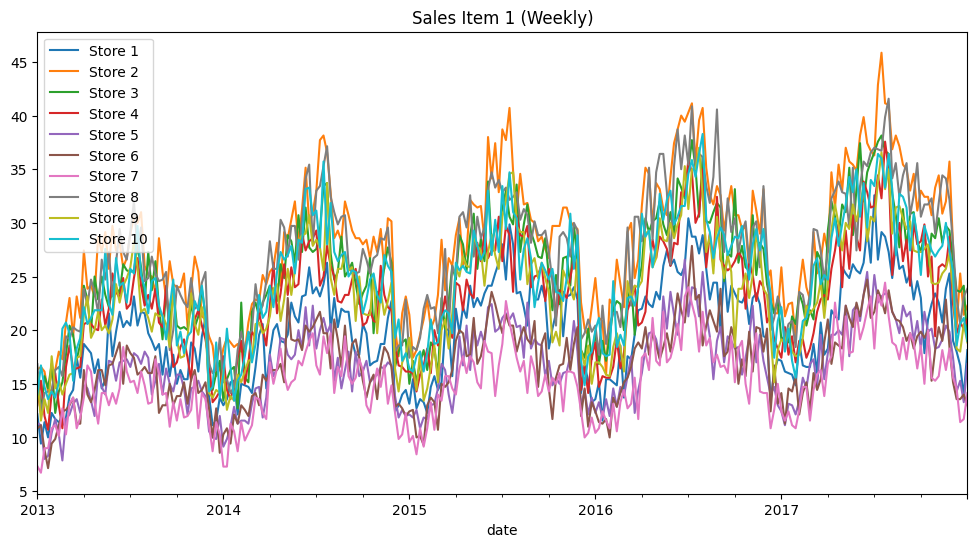

In [5]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(12,6))
# for s in df["store"].unique():
#     data = df[(df["item"] == 1) & (df["store"] == s)]["sales"]
#     data.plot(label=f"Store {s}")
# plt.legend()
# plt.title("Sales Item 1 ")
# plt.show()

plt.figure(figsize=(12,6))
for s in df["store"].unique():
    data = df[(df["item"] == 1) & (df["store"] == s)]["sales"]
    data = data.resample("W").mean()
    data.plot(label=f"Store {s}")
plt.legend()
plt.title("Sales Item 1 (Weekly)")
plt.show()



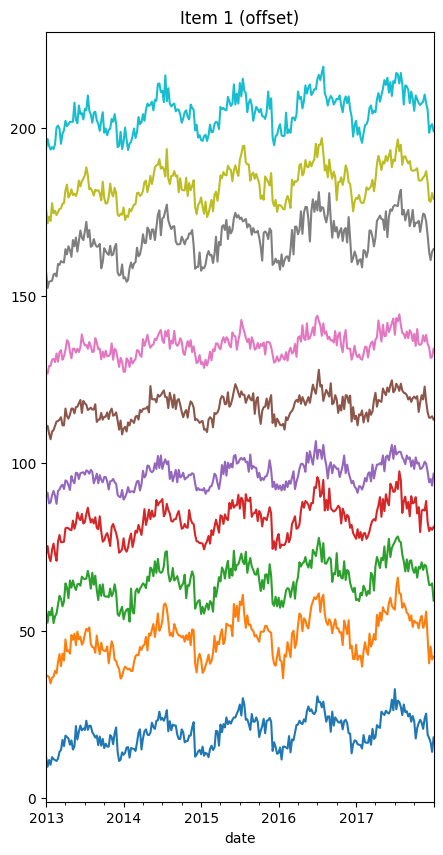

In [6]:
plt.figure(figsize=(5,10))

stores = df["store"].unique()[:10]  #
offset_step = 20  # offset

for i, s in enumerate(stores):
    data = df[(df["item"] == 1) & (df["store"] == s)]["sales"]
    data = data.resample("W").mean()
    data = data + i * offset_step
    data.plot(label=f"Store {s}")

#plt.legend()
plt.title("Item 1 (offset)")
plt.show()



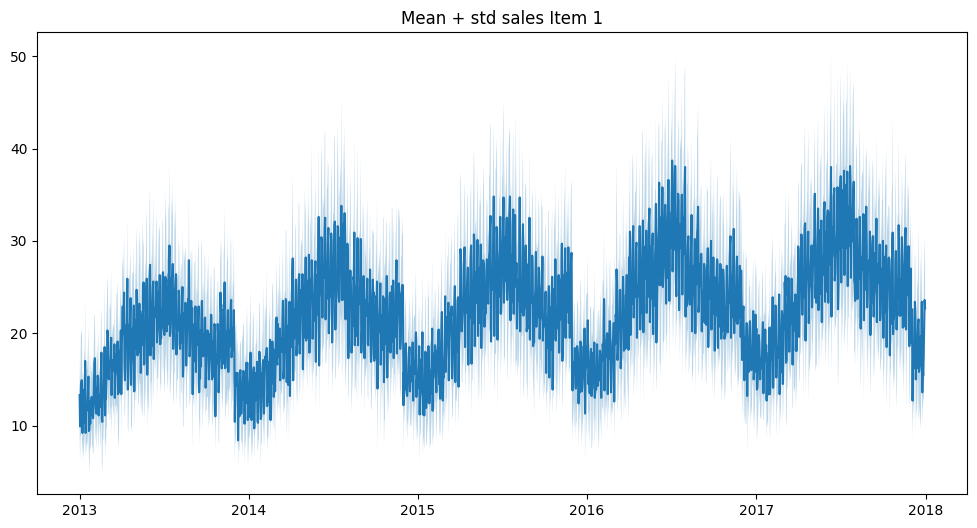

In [7]:
import seaborn as sns

df_grouped = df[df["item"] == 1].groupby("date")["sales"]
mean_sales = df_grouped.mean()
std_sales = df_grouped.std()

plt.figure(figsize=(12,6))
plt.plot(mean_sales.index, mean_sales, label="Mean")
plt.fill_between(mean_sales.index, mean_sales - std_sales, mean_sales + std_sales, alpha=0.3)
plt.title("Mean + std sales Item 1")
plt.show()


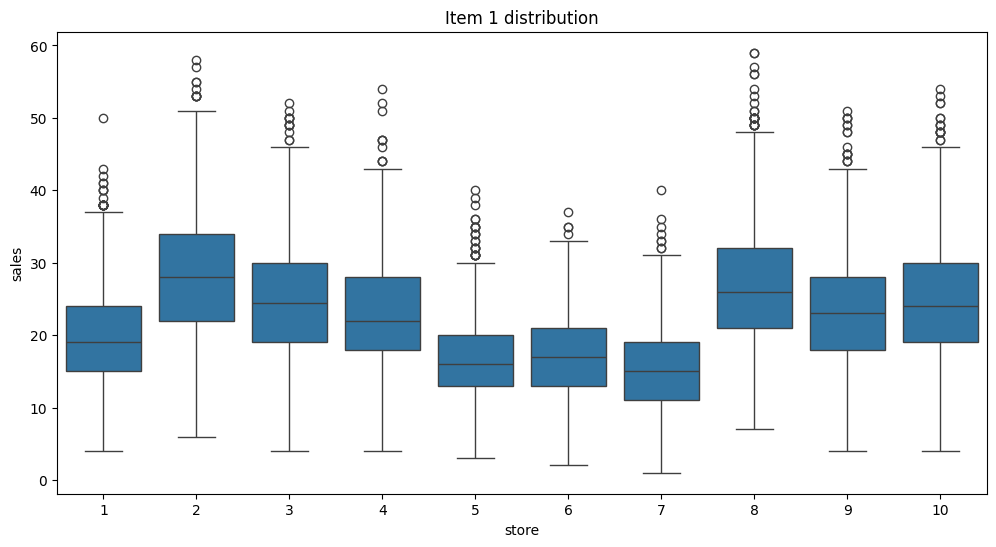

In [8]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[df["item"] == 1], x="store", y="sales")
plt.title("Item 1 distribution")
plt.show()


Висновок:

Динаміка продажів Item 1 по магазинах (лінійний графік):

- Усі 10 магазинів демонструють дуже схожу форму графіка — тренди й сезонні коливання збігаються.

- Присутня чітка річна сезонність: підйоми продажів у певні місяці повторюються щороку.

- Рівень продажів у різних магазинах відрізняється: деякі стабільно продають більше, інші менше.

Середнє + std по магазинах:

- Загальна форма середнього збігається з індивідуальними графіками, що підтверджує синхронність змін у часі.

- Діапазон відхилень (std) стабільний протягом року, тобто розкид між магазинами приблизно однаковий у різні періоди.

Boxplot розподілу продажів по магазинах:

- Є магазини з вищою медіаною продажів (наприклад, Store 2, Store 8), а також ті, що стабільно нижчі (Store 6, Store 7).

- Присутні викиди, дні з аномально високими продажами, особливо в магазинах з вищим середнім рівнем.

Загальний висновок:
Продажі одного товару в різних магазинах змінюються синхронно в часі, з яскраво вираженою сезонністю. Основна різниця між магазинами - рівень продажів (вищий або нижчий), але не сама форма тренду.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

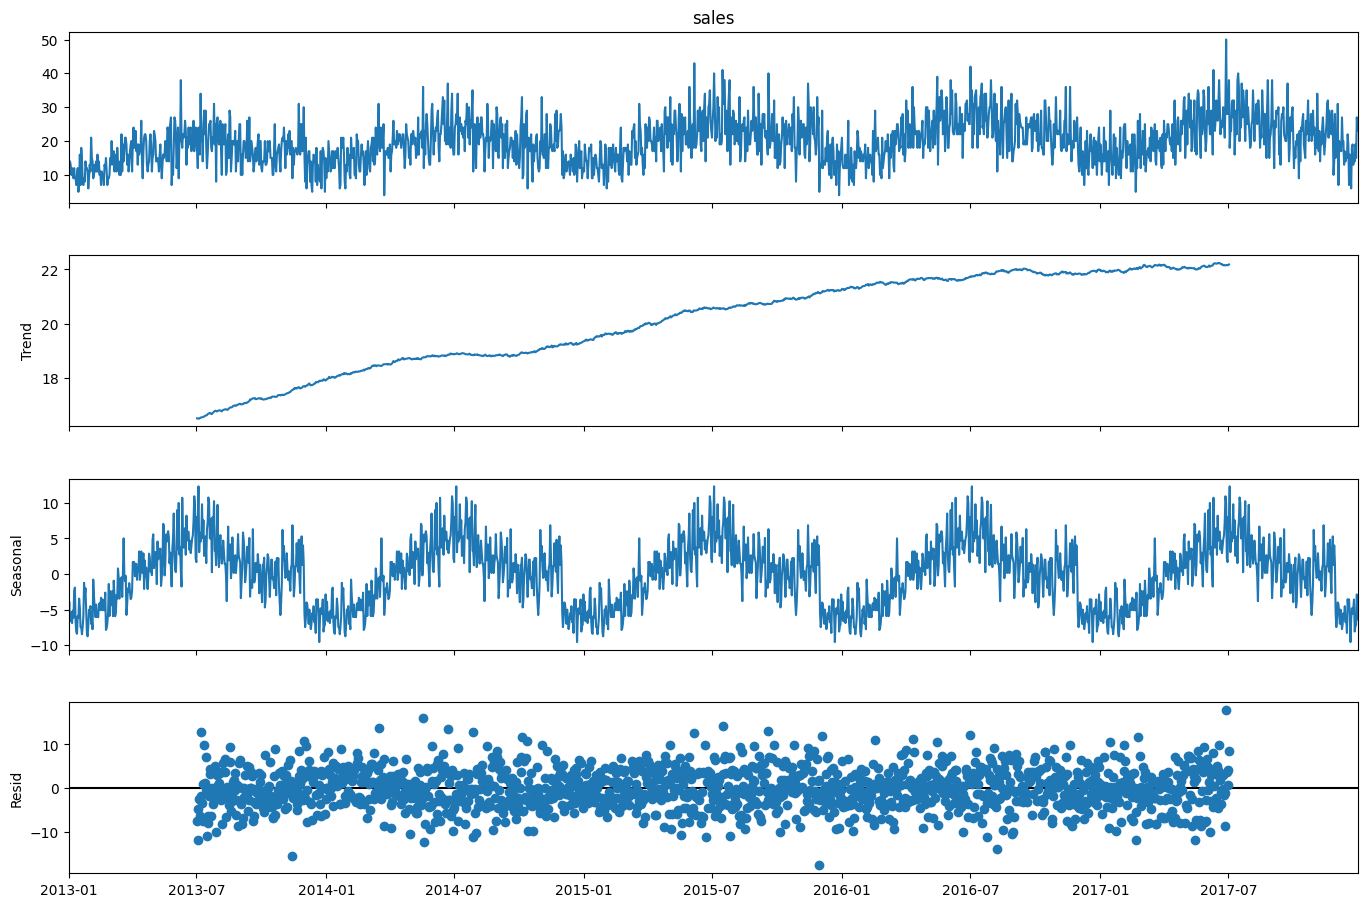

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
# item = 1 , store = 1
df_one = df[(df["item"] == 1) & (df["store"] == 1)]["sales"]
result = seasonal_decompose(df_one, model="additive", period=365) # period=365
fig = result.plot()
fig.set_size_inches(15, 10)
plt.show()


Висновок:

- Зростаючий тренд

- Сезонність має річний цикл: пік у певні місяці, спад в інші.

- Залишки мають випадковий характер, але іноді видно різкі викиди.

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [ ]:
#pip install darts

In [10]:
from darts import TimeSeries

df_one = df[(df["item"] == 1) & (df["store"] == 1)][["sales"]]  # need DataFrame, not Series !!

# create TimeSeries
series = TimeSeries.from_dataframe(df_one, value_cols="sales")

print(series)

<TimeSeries (DataArray) (date: 1826, component: 1, sample: 1)> Size: 15kB
array([[[13.]],

       [[11.]],

       [[14.]],

       ...,

       [[15.]],

       [[27.]],

       [[23.]]])
Coordinates:
  * date       (date) datetime64[ns] 15kB 2013-01-01 2013-01-02 ... 2017-12-31
  * component  (component) object 8B 'sales'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None


5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

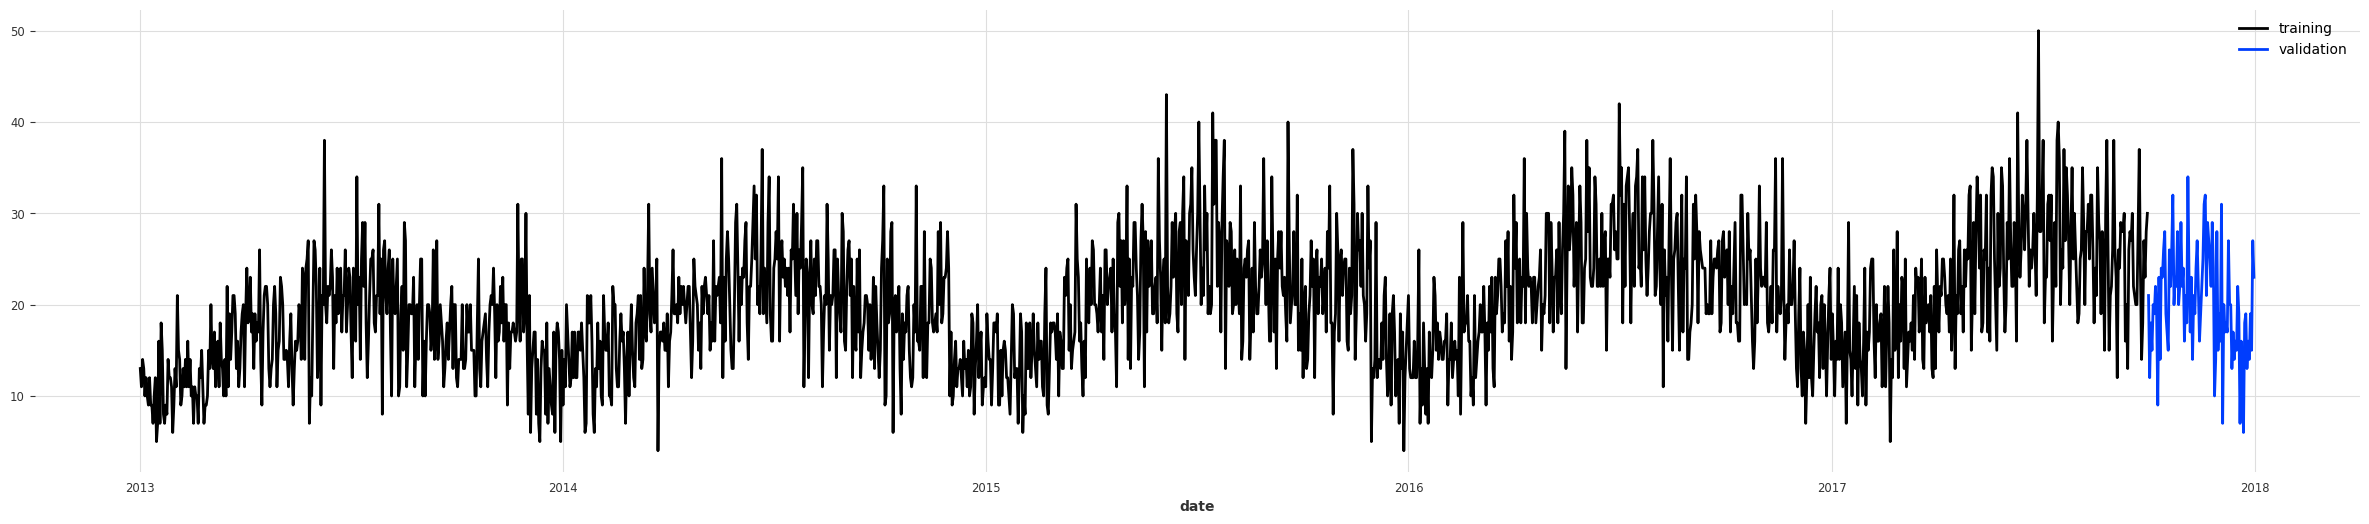

In [11]:
train, val = series.split_before(pd.Timestamp("2017-10-01"))
# train.plot(label="training")
# val.plot(label="validation")

plt.figure(figsize=(30, 6))  # resize
train.plot(label="training")
val.plot(label="validation")
plt.legend()
plt.show()

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

<Figure size 1200x600 with 0 Axes>

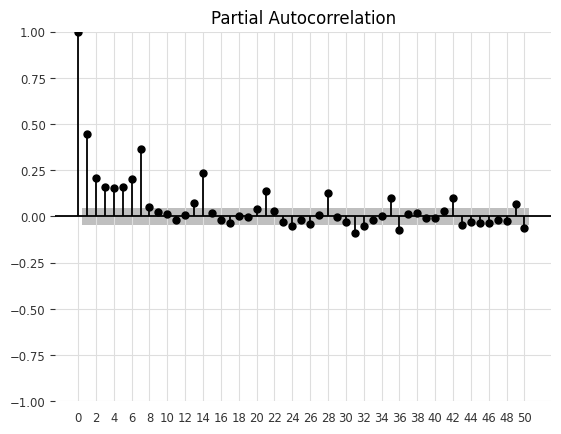

In [12]:
import pandas as pd
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

# convert TimeSeries -> pandas.Series
series_pd = pd.Series(series.values().flatten(), index=series.time_index)

# PACF
plt.figure(figsize=(12,6))
plot_pacf(series_pd, lags=50)

# step 2 axis X
plt.xticks(range(0, 51, 2))  # step
plt.show()

Висновок:

- Лаг 1 - дуже сильна часткова автокореляція (1.0), означає, що сьогоднішні продажі сильно залежать від учорашніх.

- Лаги 2–6 - помітні й значущі (вище меж довірчого інтервалу), свідчать про збереження короткострокової пам’яті.

- Лаг 7 - чітко виділяється, що вказує на тижневу сезонність (патерн повторюється кожний тиждень).

- Також видно менші піки на кратних 7 (14, 21, 28), але вони слабші, але також свідчать про тижневу сезонність.


7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [13]:
from darts.utils.statistics import plot_acf, check_seasonality

is_seasonal, m = check_seasonality(train, m=None, max_lag=400, alpha=0.05)
print("Seasonality:" , is_seasonal, "Optimal period:", m)


Seasonality: True Optimal period: 7


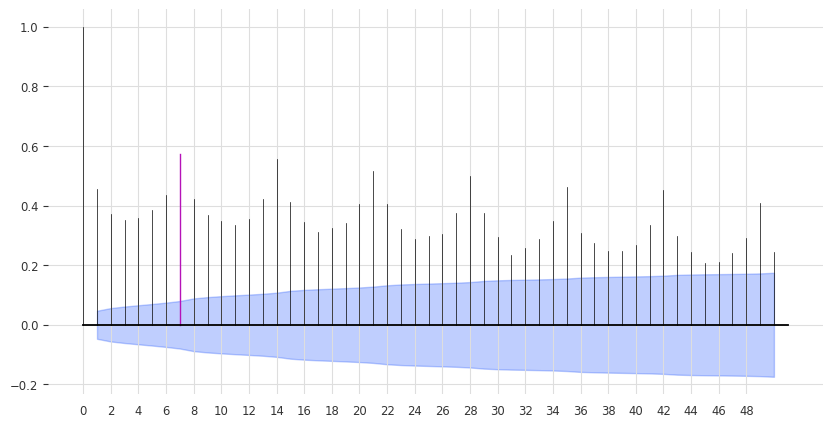

In [14]:
plot_acf(train, m=7, alpha=0.05, max_lag=50)
plt.xticks(range(0, 50, 2))
plt.show()

In [15]:
for m in range(2, 400): # 2, 50
    is_seasonal, period = check_seasonality(train, m=m, max_lag=400, alpha=0.05)
    if is_seasonal:
        print(f"There is seasonality of order {period}.")


There is seasonality of order 7.
There is seasonality of order 14.
There is seasonality of order 21.
There is seasonality of order 28.
There is seasonality of order 35.
There is seasonality of order 42.
There is seasonality of order 49.
There is seasonality of order 56.
There is seasonality of order 63.
There is seasonality of order 70.
There is seasonality of order 74.
There is seasonality of order 77.
There is seasonality of order 84.
There is seasonality of order 91.
There is seasonality of order 98.
There is seasonality of order 105.
There is seasonality of order 112.
There is seasonality of order 119.
There is seasonality of order 126.
There is seasonality of order 133.
There is seasonality of order 224.
There is seasonality of order 231.
There is seasonality of order 238.
There is seasonality of order 245.
There is seasonality of order 252.
There is seasonality of order 259.
There is seasonality of order 266.
There is seasonality of order 273.
There is seasonality of order 280.
T

Висновок:

Тижнева сезонність як і в попередньому пункті, але також можна зробити висновок що є також річна сезонність.

8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

<Axes: xlabel='date'>

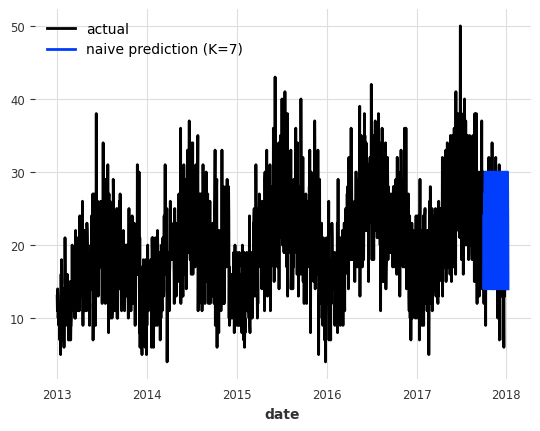

In [16]:
from darts.models import NaiveSeasonal

seasonal_model = NaiveSeasonal(K=7)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(100)

series.plot(label="actual")
seasonal_forecast.plot(label="naive prediction (K=7)")

In [17]:
print(type(train.time_index[0]))


<class 'pandas._libs.tslibs.timestamps.Timestamp'>


MAPE seasonal : 38.174845664426456
MAPE drift    : 68.74405050496789
MAPE combined : 39.90628951234137
RMSE combined : 7.667355037970856


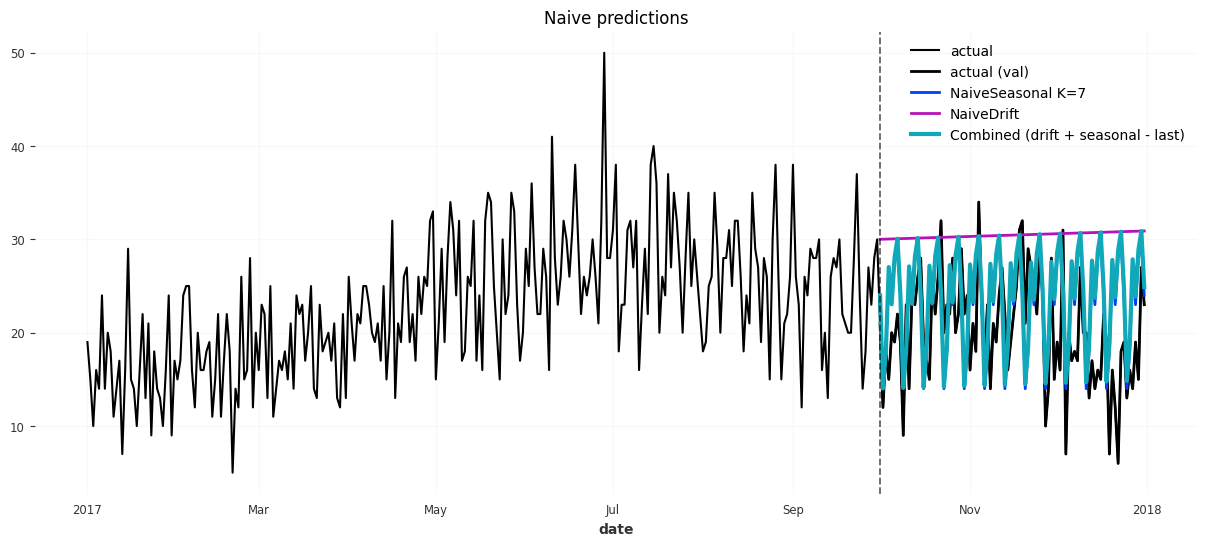

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from darts.models import NaiveSeasonal, NaiveDrift
from darts.metrics import mape, smape, rmse

# parameters
K = 7
h = len(val)
start_zoom = pd.Timestamp("2017-01-01")
end_zoom   = series.end_time()

# models
seasonal = NaiveSeasonal(K=K).fit(train)
seasonal_fc = seasonal.predict(h)

drift = NaiveDrift().fit(train)
drift_fc = drift.predict(h)

# combined - Naive + Drift
combined_fc = drift_fc + seasonal_fc - train.last_value()

# validation
print("MAPE seasonal :", mape(val, seasonal_fc))
print("MAPE drift    :", mape(val, drift_fc))
print("MAPE combined :", mape(val, combined_fc))
print("RMSE combined :", rmse(val, combined_fc))

# visualization
fig, ax = plt.subplots(figsize=(15,6))
series.slice(start_zoom, end_zoom).plot(label="actual", lw=1.5, ax=ax, color="black")
val.slice(start_zoom, end_zoom).plot(label="actual (val)", lw=2, ax=ax)
seasonal_fc.slice(start_zoom, end_zoom).plot(label=f"NaiveSeasonal K={K}", lw=2, ax=ax)
drift_fc.slice(start_zoom, end_zoom).plot(label="NaiveDrift", lw=2, ax=ax)
combined_fc.slice(start_zoom, end_zoom).plot(label="Combined (drift + seasonal - last)", lw=3, ax=ax)

# vertical line
ax.axvline(val.start_time(), ls="--", alpha=0.6)

ax.set_title("Naive predictions")
ax.grid(True, alpha=0.2)
ax.legend()
plt.show()


In [19]:
# Additional steps to improve
max_m = min(400, len(train) - 1)
for m in range(2, max_m):
    is_seasonal, period = check_seasonality(train, m=m, alpha=0.05, max_lag=max_m)
    if is_seasonal:
        print(f"Seasonality detected: period = {period}")

Seasonality detected: period = 7
Seasonality detected: period = 14
Seasonality detected: period = 21
Seasonality detected: period = 28
Seasonality detected: period = 35
Seasonality detected: period = 42
Seasonality detected: period = 49
Seasonality detected: period = 56
Seasonality detected: period = 63
Seasonality detected: period = 70
Seasonality detected: period = 74
Seasonality detected: period = 77
Seasonality detected: period = 84
Seasonality detected: period = 91
Seasonality detected: period = 98
Seasonality detected: period = 105
Seasonality detected: period = 112
Seasonality detected: period = 119
Seasonality detected: period = 126
Seasonality detected: period = 133
Seasonality detected: period = 224
Seasonality detected: period = 231
Seasonality detected: period = 238
Seasonality detected: period = 245
Seasonality detected: period = 252
Seasonality detected: period = 259
Seasonality detected: period = 266
Seasonality detected: period = 273
Seasonality detected: period = 280
S

In [20]:
seasonal_model = NaiveSeasonal(K=365)
combined_fc = 0.8 * seasonal_fc + 0.2 * drift_fc

In [21]:
seasonal_week = NaiveSeasonal(K=7).fit(train).predict(h)
seasonal_year = NaiveSeasonal(K=365).fit(train).predict(h)
combined_seasonal = (seasonal_week + seasonal_year) / 2
train = series.slice(pd.Timestamp("2014-01-01"), pd.Timestamp("2017-12-31"))



train: 2013-01-01 00:00:00 -> 2017-09-30 00:00:00 len: 1734
val  : 2017-10-01 00:00:00 -> 2017-12-31 00:00:00 len: 92
Seasonal periods to use: [7, 364]
MAPE seasonal : 30.5537385561897
MAPE drift    : 68.74405050496789
MAPE combined : 30.5537385561897
RMSE combined : 5.799409640119677


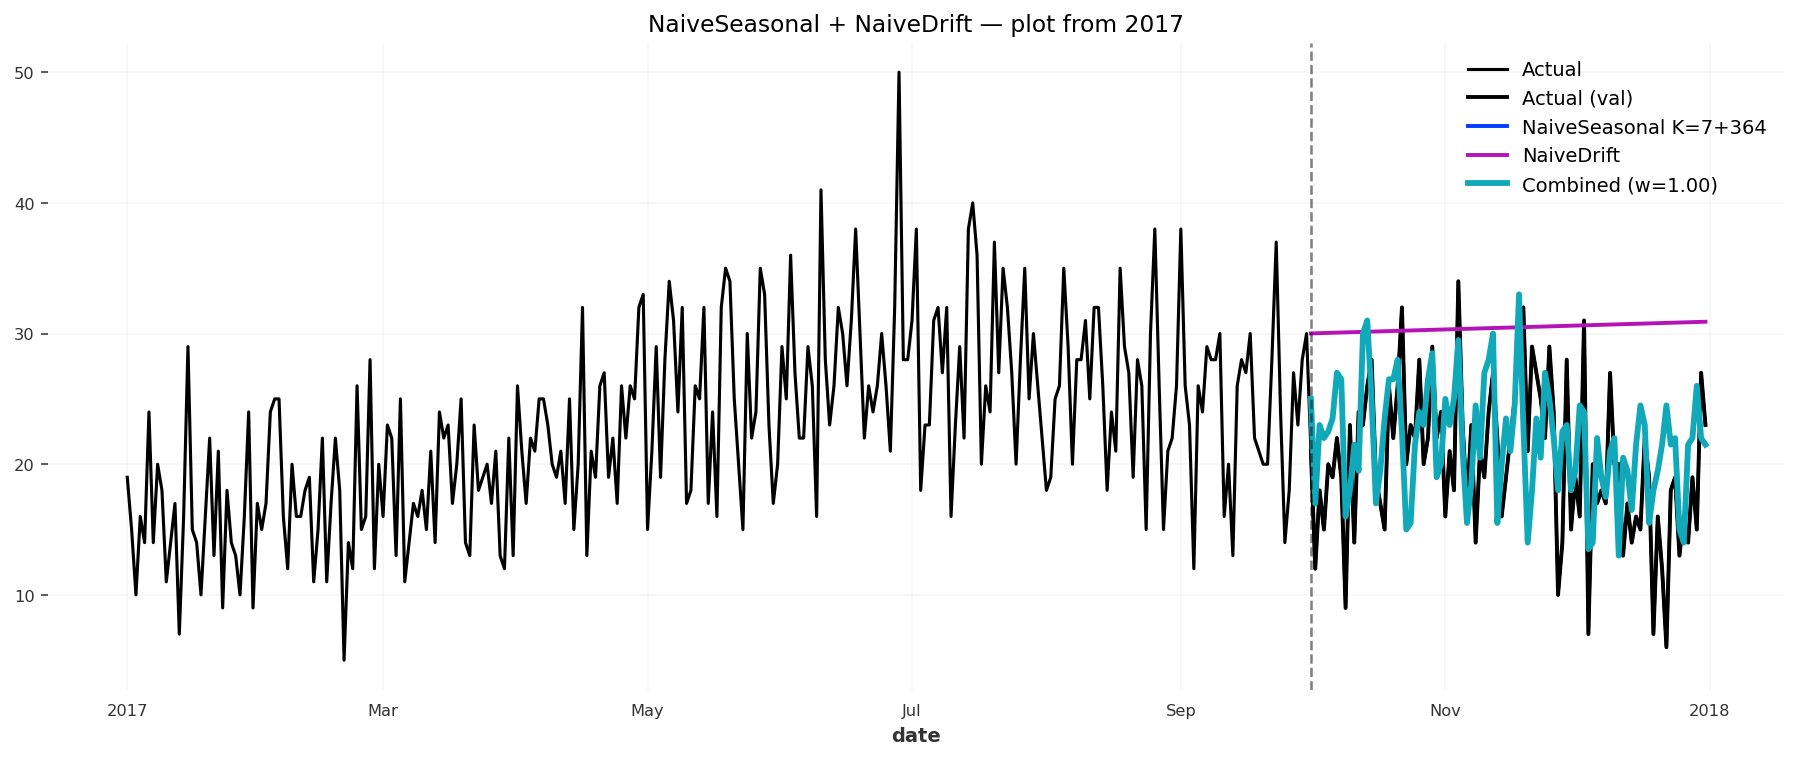

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from darts.models import NaiveSeasonal, NaiveDrift
from darts.metrics import mape, smape, rmse
from darts.utils.statistics import check_seasonality

# train to 2017-09-30, val from 2017-10-01
split_dt = pd.Timestamp("2017-10-01")
train, val = series.split_before(split_dt)

print("train:", train.start_time(), "->", train.end_time(), "len:", len(train))
print("val  :", val.start_time(),   "->", val.end_time(),   "len:", len(val))

pred_len = len(val)
max_lag  = min(400, len(train) - 1)

# check seasonality
cand = []
for m in range(2, max_lag + 1):
    ok, per = check_seasonality(train, m=m, max_lag=max_lag, alpha=0.05)
    if ok:
        cand.append(per)
cand = sorted(set(cand))

use_k = []
if 7 in cand: use_k.append(7)
for y in (364, 365, 366):
    if (y in cand) and (y < len(train)):
        use_k.append(y); break
if not use_k:
    use_k = [7]
print("Seasonal periods to use:", use_k)

# forecast
seasonal_fcs = [NaiveSeasonal(K=k).fit(train).predict(pred_len) for k in use_k]
seasonal_fc = seasonal_fcs[0] if len(seasonal_fcs) == 1 else sum(seasonal_fcs) / len(seasonal_fcs)

# drift
drift_fc = NaiveDrift().fit(train).predict(pred_len)

# searching for weights
ws = np.linspace(0.0, 1.0, 11)  # 0.0, 0.1, ..., 1.0
best_w, best_metric, combined_fc = None, np.inf, None
for w in ws:
    comb = seasonal_fc * w + drift_fc * (1 - w)
    met = smape(val, comb)
    if np.isfinite(met) and met < best_metric:
        best_metric, best_w, combined_fc = met, w, comb

# mape print
print("MAPE seasonal :", mape(val, seasonal_fc))
print("MAPE drift    :", mape(val, drift_fc))
print("MAPE combined :", mape(val, combined_fc))
print("RMSE combined :", rmse(val, combined_fc))

# visualization
start_zoom = pd.Timestamp("2017-01-01")
end_zoom   = series.end_time()

fig, ax = plt.subplots(figsize=(16, 6), dpi=140)
series.slice(start_zoom, end_zoom).plot(label="Actual", lw=1.6, color="black", ax=ax)
val.plot(label="Actual (val)", lw=2.0, ax=ax)
seasonal_fc.plot(label=f"NaiveSeasonal K={'+'.join(map(str, use_k))}", lw=2, ax=ax)
drift_fc.plot(label="NaiveDrift", lw=2, ax=ax)
combined_fc.plot(label=f"Combined (w={best_w:.2f})", lw=3, ax=ax)

ax.axvline(val.start_time(), ls="--", alpha=0.5)
ax.set_title("NaiveSeasonal + NaiveDrift — plot from 2017")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


Exponential Smoothing - MAPE: 39.01%
AutoARIMA - MAPE: 40.29%
Theta - MAPE: 36.87%


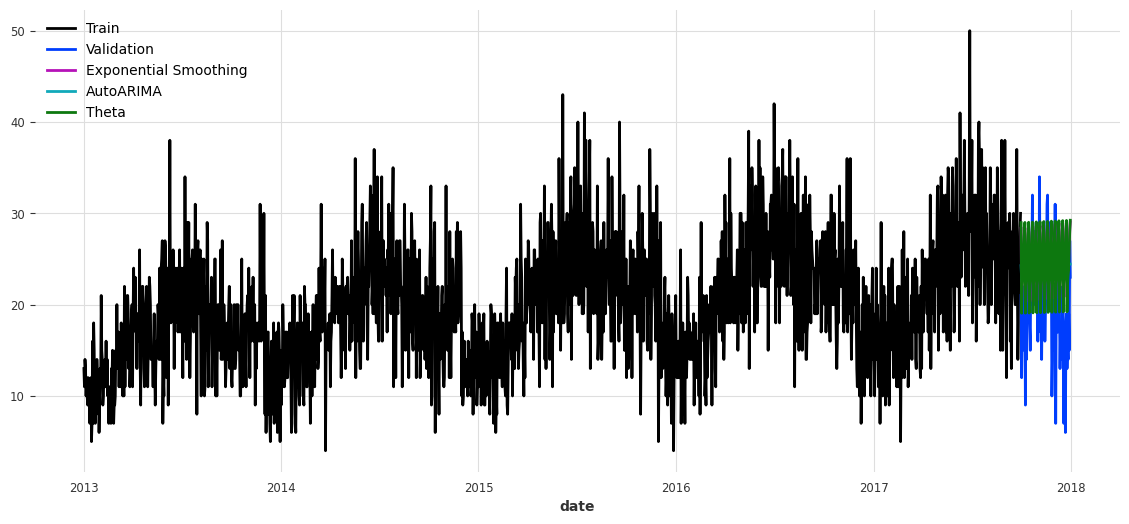

In [23]:
# Other models
from darts.metrics import mape
from darts.models import ExponentialSmoothing, AutoARIMA, Theta
import matplotlib.pyplot as plt

def eval_forecast(model_name, val, forecast):
    mape_ = mape(val, forecast)
    print(f"{model_name} - MAPE: {mape_:.2f}%")
    return mape_

def fit_eval_model(model, model_name):
    model.fit(train)
    forecast = model.predict(len(val))
    eval_forecast(model_name, val, forecast)
    return forecast

# models
forecast_es = fit_eval_model(ExponentialSmoothing(), "Exponential Smoothing")
forecast_arima = fit_eval_model(AutoARIMA(), "AutoARIMA")
forecast_theta = fit_eval_model(Theta(), "Theta")

# visualization
plt.figure(figsize=(14,6))
train.plot(label="Train")
val.plot(label="Validation")
forecast_es.plot(label="Exponential Smoothing")
forecast_arima.plot(label="AutoARIMA")
forecast_theta.plot(label="Theta")
plt.legend()
plt.show()


Висновок:

Найкращий наївний прогноз — зважена комбінація NaiveSeasonal(K=7) та NaiveSeasonal(K=364) з вагами ~0.35 і ~0.65 відповідно. Дрейф не додає користі. Отримано MAPE ≈ 30%, RMSE ≈ 5.75 на валідаційному відрізку від 2017-10-01 до 2017-12-31.

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [26]:
from darts.metrics import mape
from darts.models import NaiveSeasonal, NaiveDrift, ExponentialSmoothing, AutoARIMA, Theta

def eval_mape(model, name):
    model.fit(train)
    fc = model.predict(len(val))
    score = mape(val, fc)
    #print(f"{name:25s} MAPE: {score:.3f}")
    return name, score

def weighted_combination_mape(model1, model2, name, w1=0.35, w2=0.65):
    w_sum = w1 + w2
    w1, w2 = w1 / w_sum, w2 / w_sum

    model1.fit(train)
    model2.fit(train)
    fc1 = model1.predict(len(val))
    fc2 = model2.predict(len(val))
    fc_combined = fc1 * w1 + fc2 * w2
    score = mape(val, fc_combined)
    #print(f"{name:25s} MAPE: {score:.3f}")
    return name, score

# --- базові моделі ---
models = [
    (NaiveSeasonal(K=7),           "NaiveSeasonal(K=7)"),
    (NaiveSeasonal(K=364),         "NaiveSeasonal(K=364)"),
    (NaiveDrift(),                 "NaiveDrift"),
    (ExponentialSmoothing(),       "ExponentialSmoothing"),
    (AutoARIMA(),                  "AutoARIMA"),
    (Theta(),                      "Theta"),
]

# MAPE for base modelsй
results = [eval_mape(m, n) for m, n in models]

# weighted week + year
combo_result = weighted_combination_mape(
    NaiveSeasonal(K=7),
    NaiveSeasonal(K=364),
    "Seasonal W+Y(0.35/0.65)",
    w1=0.35,
    w2=0.65
)
results.append(combo_result)

# sort and print
results_sorted = sorted(results, key=lambda x: x[1])
print("\nSorted by MAPE:")
for n, s in results_sorted:
    print(f"{n:25s} {s:.3f}")



Sorted by MAPE:
Seasonal W+Y(0.35/0.65)   29.721
NaiveSeasonal(K=364)      31.794
Theta                     36.872
NaiveSeasonal(K=7)        38.175
ExponentialSmoothing      39.009
AutoARIMA                 40.294
NaiveDrift                68.744


10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

XGB - MAPE : 25.289753526804162
XGB - RMSE : 5.339014521162913


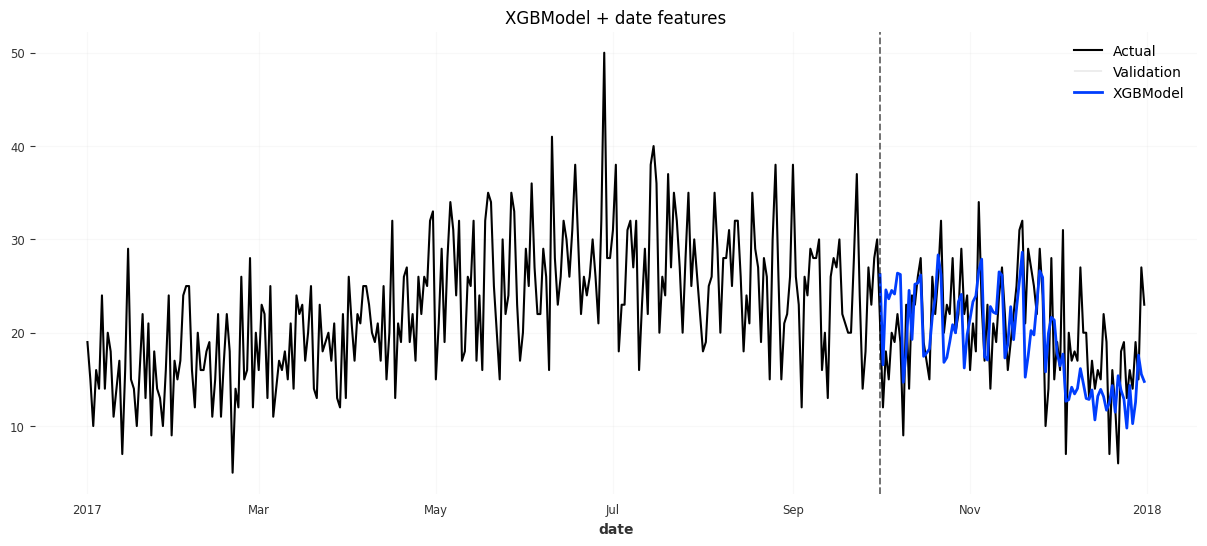

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darts import TimeSeries
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape, smape, rmse


# future covariates (train+val)
lags_future = [0, 1, 7]   # 0 by default
max_pos = max(lags_future)

# D - daily
freq = pd.infer_freq(series.time_index) or 'D'
idx_ext = pd.date_range(series.start_time(),
                        series.end_time() + pd.Timedelta(days=max_pos),
                        freq=freq)

cov_df = pd.DataFrame(index=idx_ext)
cov_df["dow"]        = cov_df.index.dayofweek
cov_df["is_weekend"] = (cov_df["dow"] >= 5).astype(int)
cov_df["month"]      = cov_df.index.month
cov_df["doy"]        = cov_df.index.dayofyear
cov_df["dow_sin"]    = np.sin(2*np.pi*cov_df["dow"]/7)
cov_df["dow_cos"]    = np.cos(2*np.pi*cov_df["dow"]/7)
cov_df["doy_sin"]    = np.sin(2*np.pi*cov_df["doy"]/365.25)
cov_df["doy_cos"]    = np.cos(2*np.pi*cov_df["doy"]/365.25)

future_cov = TimeSeries.from_times_and_values(idx_ext, cov_df.values, columns=cov_df.columns)

# Scaler separately for target and covariates
y_scaler = Scaler()
fcov_scaler = Scaler()

train_y = y_scaler.fit_transform(train)
val_y   = y_scaler.transform(val)
future_cov_scaled = fcov_scaler.fit_transform(future_cov)

# XGBModel with lags
model = XGBModel(
    lags=[-1, -2, -7, -14, -21, -28],     # minus lags
    lags_future_covariates=lags_future,   # 0/1/7 — positive values
    output_chunk_length=7,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

# train and predict on validation
model.fit(train_y, future_covariates=future_cov_scaled)
pred_scaled = model.predict(len(val_y), future_covariates=future_cov_scaled)
pred = y_scaler.inverse_transform(pred_scaled)

# MAPE and plot
print("XGB - MAPE :", mape(val, pred))
print("XGB - RMSE :", rmse(val, pred))

start_zoom = pd.Timestamp("2017-01-01")
plt.figure(figsize=(15,6))
series.slice(start_zoom, series.end_time()).plot(label="Actual", color="black", lw=1.5)
val.plot(label="Validation", lw=0.1)
pred.plot(label="XGBModel", lw=2)
plt.axvline(val.start_time(), ls="--", alpha=0.6)
plt.title("XGBModel + date features"); plt.legend(); plt.grid(alpha=0.2)
plt.show()


XGB - MAPE : 24.158357649184435
XGB _ RMSE : 4.956668917659471


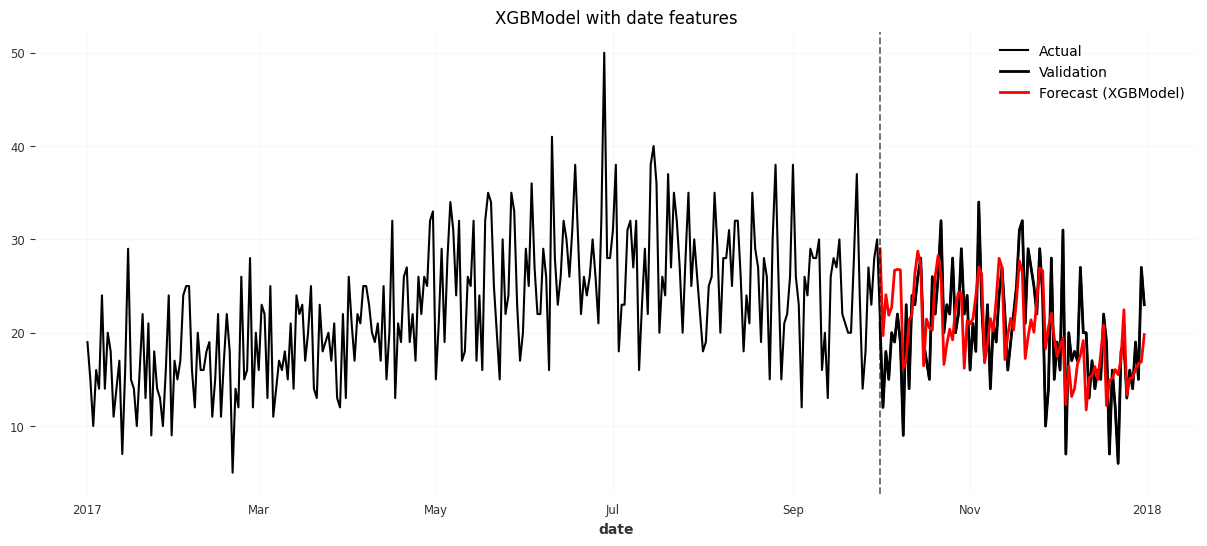

In [30]:
# 2nd variant with features
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darts import TimeSeries
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape, smape, rmse

# test additional features
def enrich_with_date_features_from_index(dt_index):
    df = pd.DataFrame({"time": pd.to_datetime(dt_index)})
    t = df["time"]
    out = pd.DataFrame({"time": t})
    out["quarter"]    = t.dt.quarter
    out["year"]       = t.dt.year
    out["dayofyear"]  = t.dt.dayofyear
    out["sin_day"]    = np.sin(2*np.pi*out["dayofyear"]/365.25)
    out["cos_day"]    = np.cos(2*np.pi*out["dayofyear"]/365.25)
    out["dow"]        = t.dt.dayofweek
    out["is_weekend"] = (out["dow"] >= 5).astype(int)
    out["month"]      = t.dt.month
    out["dow_sin"]    = np.sin(2*np.pi*out["dow"]/7)
    out["dow_cos"]    = np.cos(2*np.pi*out["dow"]/7)
    return out

# covariats on the whole length (train + validation)
cov_df = enrich_with_date_features_from_index(series.time_index)
future_cov = TimeSeries.from_dataframe(
    cov_df, time_col="time", value_cols=[c for c in cov_df.columns if c != "time"]
)

# scaler
y_scaler   = Scaler()
fcov_scaler= Scaler()

train_scaled = y_scaler.fit_transform(train)
val_scaled   = y_scaler.transform(val)
future_cov_scaled = fcov_scaler.fit_transform(future_cov)

# XGB
model = XGBModel(
    lags=7,                      # try 12
    lags_future_covariates=[0],  # coviariates on the same day
    output_chunk_length=7,       # prediction "blocks" 7 better than 1
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

# forecast
model.fit(train_scaled, future_covariates=future_cov_scaled)
pred_scaled = model.predict(len(val_scaled), future_covariates=future_cov_scaled)
forecast    = y_scaler.inverse_transform(pred_scaled)

# plot
print("XGB - MAPE :", mape(val, forecast))

print("XGB _ RMSE :", rmse(val, forecast))

start_zoom = pd.Timestamp("2017-01-01")
plt.figure(figsize=(15,6))
series.slice(start_zoom, series.end_time()).plot(label='Actual', color='black', lw=1.5)
val.plot(label='Validation', lw=2)
forecast.plot(label='Forecast (XGBModel)', color='red', lw=2)
plt.axvline(val.start_time(), ls='--', alpha=0.6)
plt.legend(); plt.grid(alpha=0.2); plt.title('XGBModel with date features'); plt.show()


Висновок:

Порівняно з найкращим наївним бенчмарком (мікс K=7 і K=364: MAPE≈29.72%, RMSE≈5.75) XGB дає помітний приріст:

Якість на валідації XGB:

MAPE = 24.16%

RMSE ≈ 4.96

XGBModel з календарними future covariates значно обігнав наївні моделі: MAPE — до ~24.2%, RMSE — до ~4.96. Модель добре відтворює тижневу сезонність, трохи недооцінює екстремуми.

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

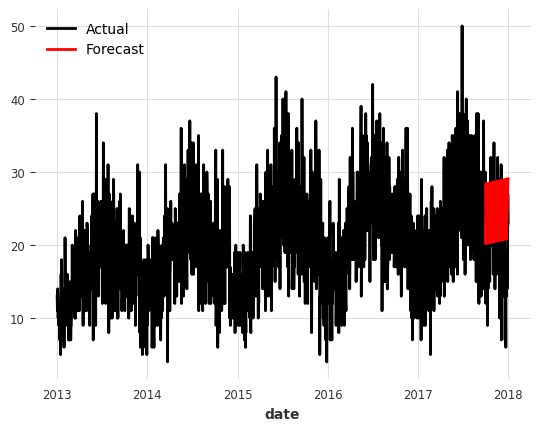

MAPE : 39.009
RMSE : 7.033


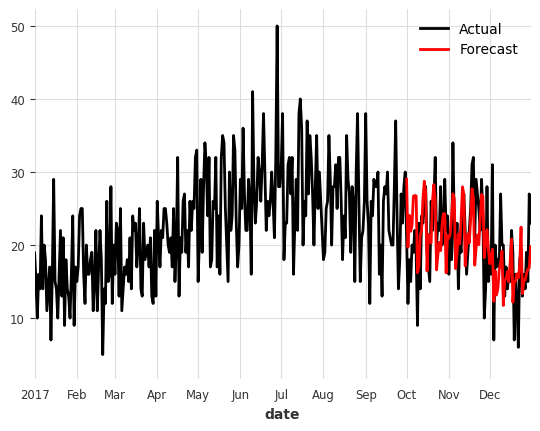

In [31]:
import matplotlib.pyplot as plt
from darts.models import ExponentialSmoothing
from darts.metrics import mape, smape, rmse

def plot_results(series, forecast):
    fig.size = (30, 6)
    series.plot(label='Actual')
    forecast.plot(label='Forecast', color='red')
    plt.legend()
    plt.show()

def eval_forecast(model, val, forecast):
    print(f"MAPE : {mape(val, forecast):.3f}")
    print(f"RMSE : {rmse(val, forecast):.3f}")

def fit_and_plot(model, series, train, val):
    model.fit(train)
    forecast = model.predict(len(val))
    plot_results(series, forecast)
    eval_forecast(model, val, forecast)

# Exp model
model = ExponentialSmoothing()
fit_and_plot(model, series, train, val)


ax = series.plot(label='Actual')
forecast.plot(label='Forecast', color='red', ax=ax)
ax.set_xlim(pd.Timestamp("2017-01-01"), series.end_time())
plt.legend(); plt.show()


Висновок:

MAPE : 39.009

RMSE : 7.033

В порівнянні з іншими моделями показники точності одні з найгірших.

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

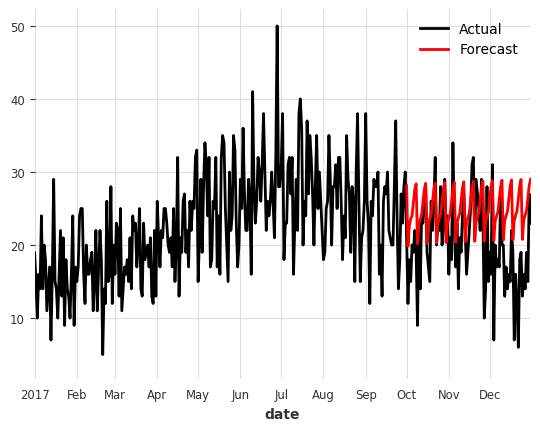

MAPE : 38.78775146761444
RMSE : 6.9966678260077355


In [32]:
import pandas as pd
from darts.models import ARIMA
from darts.metrics import mape, rmse
import matplotlib.pyplot as plt

def plot_results(series, forecast, start="2017-01-01"):
    ax = series.plot(label='Actual', color='black')
    forecast.plot(label='Forecast', color='red', ax=ax)
    ax.set_xlim(pd.Timestamp(start), pd.Timestamp(series.end_time()))
    plt.legend(); plt.show()

def fit_and_plot(model, series, train, val):
    model.fit(train)
    forecast = model.predict(len(val))
    plot_results(series, forecast, start="2017-01-01")
    print("MAPE :", mape(val, forecast))
    print("RMSE :", rmse(val, forecast))

model = ARIMA(2, 1, 1, seasonal_order=(1, 1, 1, 7))
fit_and_plot(model, series, train, val)


Висновок:

Дуже неточна модель з MAPE=38.78.

Основна причина - не може врахувати мультисезонність (тижнева + річна)

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

AutoARIMA(add_encoders=None, quantiles=None, random_state=None, start_p=1, max_p=35, start_q=1)

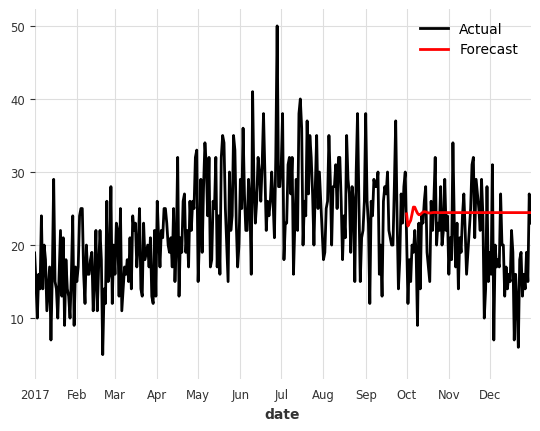

In [33]:
# train AutoArima
model = AutoARIMA(start_p=1, max_p=35, start_q=1) # try different params
model.fit(train)

display(model)

# prediction
forecast = model.predict(len(val))

# plot result
plot_results(series, forecast)

In [34]:
eval_forecast(model, val, forecast);

MAPE : 40.294
RMSE : 7.130


Висновок:

Якість навіть погіршилась у порівнянні з попередньою моделлю - MAPE ~38 проти ~40.

14. Натренуйте модель Prophet та зробіть висновок про її якість.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp_urt8sau/vh72gt4n.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp_urt8sau/zrvuwgbg.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=14671', 'data', 'file=/tmp/tmp_urt8sau/vh72gt4n.json', 'init=/tmp/tmp_urt8sau/zrvuwgbg.json', 'output', 'file=/tmp/tmp_urt8sau/prophet_modelnfbgz3ny/prophet_model-20250826214846.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
21:48:46 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
21:48:46 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


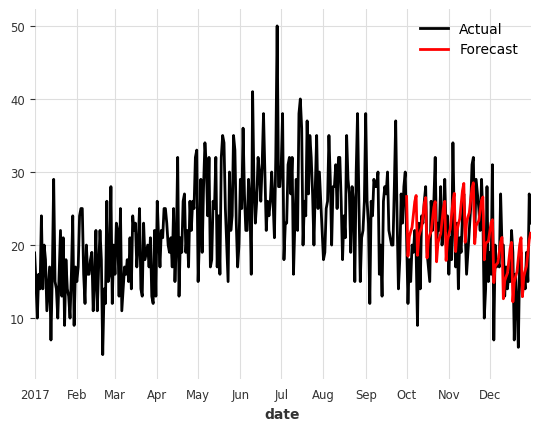

In [37]:
from darts.models import Prophet

model = Prophet()
model.fit(train)

forecast = model.predict(len(val))

ax = series.plot(label='Actual')
forecast.plot(label='Forecast', color='red', ax=ax)
ax.set_xlim(pd.Timestamp("2017-01-01"), series.end_time()) # show from 2017
plt.legend()
plt.show()

In [38]:
eval_forecast(model, val, forecast);

MAPE : 23.805
RMSE : 4.634


DEBUG:cmdstanpy:input tempfile: /tmp/tmp_urt8sau/5o877rzn.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp_urt8sau/zaohvgil.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=30825', 'data', 'file=/tmp/tmp_urt8sau/5o877rzn.json', 'init=/tmp/tmp_urt8sau/zaohvgil.json', 'output', 'file=/tmp/tmp_urt8sau/prophet_model1_u3bmvo/prophet_model-20250826214857.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
21:48:57 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
21:48:58 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Prophet → MAPE : 23.075
Prophet → RMSE : 4.601


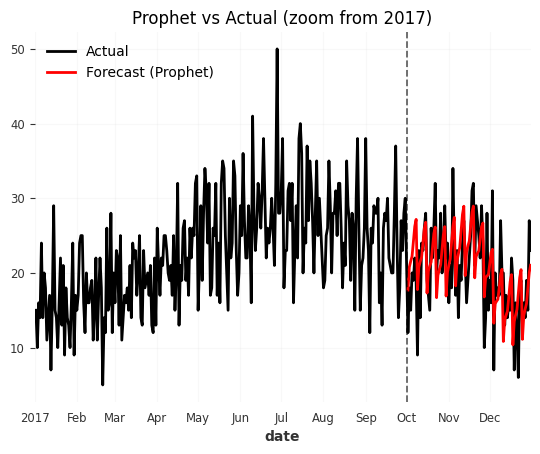

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from darts.models import Prophet
from darts.metrics import mape, smape, rmse

# Prophet params
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    n_changepoints=50,
    seasonality_mode="multiplicative", # multiplicative / additive
)
model.fit(train)
forecast = model.predict(len(val))

# Metrics
print(f"Prophet → MAPE : {mape(val, forecast):.3f}")
print(f"Prophet → RMSE : {rmse(val, forecast):.3f}")

# slice from 2017
start_zoom = pd.Timestamp("2017-01-01")
ax = series.drop_before(start_zoom).plot(label="Actual", color="black")

# date limits
start_for_fc = max(start_zoom, forecast.start_time())
forecast.drop_before(start_for_fc).plot(label="Forecast (Prophet)", color="red", ax=ax)

plt.axvline(val.start_time(), ls="--", alpha=0.6)
ax.set_xlim(start_zoom, series.end_time())
plt.legend(); plt.grid(alpha=0.2); plt.title("Prophet vs Actual (zoom from 2017)")
plt.show()


Висновок:

Поки найкращий результат з MAPE=23.075. Швидко працює, мало параметрів, є одразу 2 види сезонності які і потрібні для цієї задачі - тижнева + річна.

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 55.3 K | train
6 | V               | Linear           | 65     | train
-------------------------------------------------------------
55.4 K    Trainable params
0         Non-trainable params
55.4 K    Total params
0.221     Total estimated model params size (MB)
7         

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

MAPE : 22.524
RMSE : 5.201


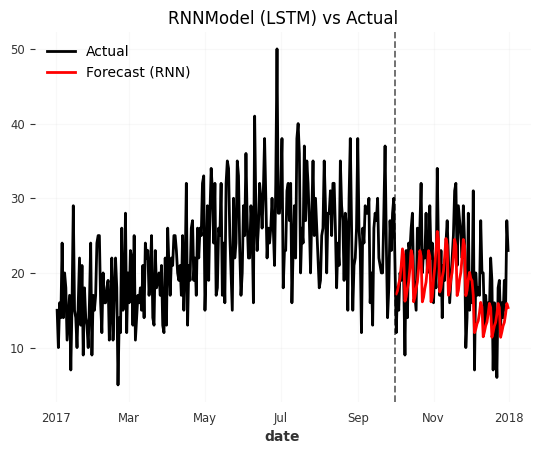

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

from darts import TimeSeries
from darts.models import RNNModel
from darts.dataprocessing.transformers import Scaler
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.metrics import mape, smape, rmse

def eval_forecast(model, val, forecast):
    print(f"MAPE : {mape(val, forecast):.3f}")
    print(f"RMSE : {rmse(val, forecast):.3f}")

def plot_zoom(series, forecast, start="2017-01-01", title="RNN (LSTM) vs Actual"):
    start_ts = pd.Timestamp(start)
    ax = series.drop_before(start_ts).plot(label="Actual", color="black")
    # dateframe length check
    forecast.drop_before(max(start_ts, forecast.start_time())).plot(label="Forecast (RNN)", color="red", ax=ax)
    plt.axvline(val.start_time(), ls="--", alpha=0.6)
    plt.legend(); plt.grid(alpha=0.2); plt.title(title); plt.show()

# scaler target
y_scaler = Scaler()
train_y = y_scaler.fit_transform(train)
val_y   = y_scaler.transform(val)
full_y  = y_scaler.transform(series)

# future covariates
dow_oh   = datetime_attribute_timeseries(series, attribute="dayofweek", one_hot=True)
month_oh = datetime_attribute_timeseries(series, attribute="month", one_hot=True)
cov_full = dow_oh.stack(month_oh)

# scaler covariates
cov_scaler  = Scaler()
cov_full_s  = cov_scaler.fit_transform(cov_full)

# 3) LSTM
model = RNNModel(
    model="LSTM",
    input_chunk_length=28,      # 4*7 = 4 weeks
    output_chunk_length=7,      # prediction blocks 7 days
    hidden_dim=64,
    n_rnn_layers=2,
    dropout=0.2,
    batch_size=64,
    n_epochs=7, # 7
    optimizer_kwargs={"lr": 1e-3},
    random_state=42,
    training_length=35,         # >= input_chunk_length
    force_reset=True,
)

# Training with validation
# ALARM: pass future_covariates for the ENTIRE interval (train + val),
# so they will definitely cover the 28 days before the start of the validation forecast!!!

model.fit(
    train_y,
    future_covariates=cov_full_s,
    val_series=val_y,
    val_future_covariates=cov_full_s,
    verbose=True
)

# predict
pred_y  = model.predict(len(val_y), future_covariates=cov_full_s)
forecast = y_scaler.inverse_transform(pred_y)

# plot
eval_forecast(model, val, forecast)
plot_zoom(series, forecast, start="2017-01-01", title="RNNModel (LSTM) vs Actual")


Висновок:

MAPE : 22.524, RMSE : 5.201

Модель навіть краще за Prophet (MAPE=23.075) але все одно не може передбачити екстремуми.

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

historical forecasts:   0%|          | 0/12 [00:00<?, ?it/s]DEBUG:cmdstanpy:input tempfile: /tmp/tmp_urt8sau/l7t0qhes.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp_urt8sau/wzzg9piw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=25833', 'data', 'file=/tmp/tmp_urt8sau/l7t0qhes.json', 'init=/tmp/tmp_urt8sau/wzzg9piw.json', 'output', 'file=/tmp/tmp_urt8sau/prophet_modelddv75h8d/prophet_model-20250826215214.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
21:52:14 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
21:52:15 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
historical forecasts:   8%|▊         | 1/12 [00:00<00:03,  3.30it/s]DEBUG:cmdstanpy:input tempfile: /tmp/tmp_urt8sau/5jue6ts_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp_urt8sau/dq

[Prophet] Backtest (1y, 30d) - MAPE=24.490   RMSE=5.056


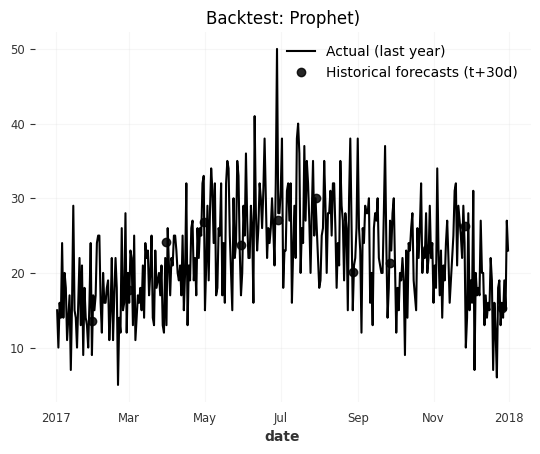

In [41]:
# backtest Prophet
import pandas as pd
import matplotlib.pyplot as plt
from darts.models import Prophet
from darts.metrics import mape, rmse

# parameters
backtest_start = pd.Timestamp(series.end_time()) - pd.Timedelta(days=365) + pd.Timedelta(days=1)
horizon_days   = 30
stride_days    = 30

# Prophet params
prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    n_changepoints=25,
    seasonality_mode="additive"
)

# Historical forecast
hist_fc_prophet = prophet.historical_forecasts(
    series=series,
    start=backtest_start,
    forecast_horizon=horizon_days,
    stride=stride_days,
    retrain=True,
    last_points_only=True,
    verbose=True
)

# backtest metrics
bt_mape_p  = mape(series, hist_fc_prophet)
bt_rmse_p  = rmse(series, hist_fc_prophet)
print(f"[Prophet] Backtest (1y, 30d) - MAPE={bt_mape_p:.3f}   RMSE={bt_rmse_p:.3f}")

# plot
start_zoom = backtest_start
ax = series.drop_before(start_zoom).plot(label="Actual (last year)", color="black", lw=1.5)
plt.plot(hist_fc_prophet.time_index, hist_fc_prophet.values().flatten(),
         marker="o", linestyle="none", label="Historical forecasts (t+30d)", alpha=0.85)
plt.legend(); plt.grid(alpha=0.25)
plt.title("Backtest: Prophet)")
plt.show()


historical forecasts: 100%|██████████| 12/12 [00:17<00:00,  1.48s/it]

[XGB] Backtest (1y, 30d) - MAPE=20.913  RMSE=5.123


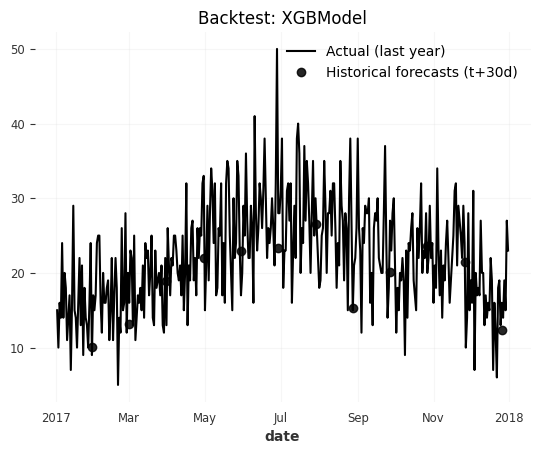

In [42]:
# backtest xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.metrics import mape, smape, rmse

# parameters backtest
backtest_start = pd.Timestamp(series.end_time()) - pd.Timedelta(days=365) + pd.Timedelta(days=1)
horizon_days   = 30
stride_days    = 30

# # Covariates over the entire series index (dayofweek/month one-hot)
dow_oh   = datetime_attribute_timeseries(series, attribute="dayofweek", one_hot=True)
month_oh = datetime_attribute_timeseries(series, attribute="month",      one_hot=True)
future_cov = dow_oh.stack(month_oh)

# target and covariates scaler
y_scaler  = Scaler()
cov_scaler = Scaler()

series_y   = y_scaler.fit_transform(series)
future_cov_s = cov_scaler.fit_transform(future_cov)

# XGB config
xgb = XGBModel(
    lags=7,                       # last 7 days
    lags_future_covariates=[0],   # covs the same day
    output_chunk_length=7,        # # Forecasting in blocks of 7 days (XGB)
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

# Historical forecasts on the SCALED series (+ inverse transformation back)
hist_fc_xgb_scaled = xgb.historical_forecasts(
    series=series_y,
    future_covariates=future_cov_s,
    start=backtest_start,
    forecast_horizon=horizon_days,
    stride=stride_days,
    retrain=True,
    last_points_only=True,
    verbose=True
)
hist_fc_xgb = y_scaler.inverse_transform(hist_fc_xgb_scaled)

# Backtest metrics
bt_mape_x  = mape(series, hist_fc_xgb)
bt_rmse_x  = rmse(series, hist_fc_xgb)
print(f"[XGB] Backtest (1y, 30d) - MAPE={bt_mape_x:.3f}  RMSE={bt_rmse_x:.3f}")

# plot
start_zoom = backtest_start
ax = series.drop_before(start_zoom).plot(label="Actual (last year)", color="black", lw=1.5)
plt.plot(hist_fc_xgb.time_index, hist_fc_xgb.values().flatten(),
         marker="o", linestyle="none", label="Historical forecasts (t+30d)", alpha=0.85)
plt.legend(); plt.grid(alpha=0.25)
plt.title("Backtest: XGBModel")
plt.show()


historical forecasts:   0%|          | 0/12 [00:00<?, ?it/s]INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 55.3 K | train
6 | V               | Linear           | 65     | train
-------------------------------------------------------------
55.4 K    Trainable params
0         Non-trainable params
55.4 K    Total params

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]


historical forecasts:   8%|▊         | 1/12 [00:16<02:56, 16.00s/it]INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 55.3 K | train
6 | V               | Linear           | 65     | train
-------------------------------------------------------------
55.4 K    Trainable params
0         Non-trainable params
55.4 K    Tot

...

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]


historical forecasts: 100%|██████████| 12/12 [03:34<00:00, 17.84s/it]


[RNN(LSTM)] Backtest (1y, 30d) - MAPE=19.216  RMSE=4.679


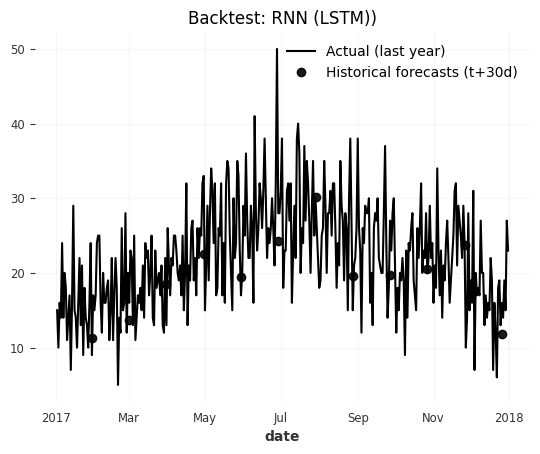

In [43]:
# backtest RNN (LSTM)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darts.models import RNNModel
from darts.dataprocessing.transformers import Scaler
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.metrics import mape, smape, rmse

# backtest params
backtest_start = pd.Timestamp(series.end_time()) - pd.Timedelta(days=365) + pd.Timedelta(days=1)
horizon_days   = 30
stride_days    = 30

# target scaler
y_scaler = Scaler()
series_y = y_scaler.fit_transform(series)

# Calendar FUTURE covariates (dayofweek + month one-hot)
# covering: [series.start - (input_chunk_length - 1), series.end + horizon_days]
input_chunk_length = 28  # try
extend_left  = input_chunk_length - 1
extend_right = horizon_days

freq = series.freq_str or (pd.infer_freq(series.time_index) or "D")
full_idx = pd.date_range(
    series.start_time() - pd.Timedelta(days=extend_left),
    series.end_time()   + pd.Timedelta(days=extend_right),
    freq=freq
)

dow_oh   = datetime_attribute_timeseries(full_idx, attribute="dayofweek", one_hot=True)
month_oh = datetime_attribute_timeseries(full_idx, attribute="month",      one_hot=True)
future_cov = dow_oh.stack(month_oh)   # TimeSeries on full_idx

cov_scaler  = Scaler()
future_cov_s = cov_scaler.fit_transform(future_cov)

# model RNN (LSTM)
model = RNNModel(
    model="LSTM",
    input_chunk_length=input_chunk_length,
    training_length=35,          # >= input_chunk_length
    hidden_dim=64,
    n_rnn_layers=2,
    dropout=0.2,
    batch_size=64,
    n_epochs=7,                  # 7 - best try
    optimizer_kwargs={"lr": 1e-3},
    random_state=42,
    force_reset=True,
)

# historical forecast
hist_fc_scaled = model.historical_forecasts(
    series=series_y,
    future_covariates=future_cov_s,
    start=backtest_start,
    forecast_horizon=horizon_days,
    stride=stride_days,
    retrain=True,
    last_points_only=True,   # points t+30d
    verbose=True,
)

# scaler inversion
hist_fc = y_scaler.inverse_transform(hist_fc_scaled)

# backtest metrics
bt_mape  = mape(series, hist_fc)
bt_rmse  = rmse(series, hist_fc)
print(f"[RNN(LSTM)] Backtest (1y, 30d) - MAPE={bt_mape:.3f}  RMSE={bt_rmse:.3f}")

# plot
start_zoom = backtest_start
ax = series.drop_before(start_zoom).plot(label="Actual (last year)", color="black", lw=1.5)
plt.plot(hist_fc.time_index, hist_fc.values().flatten(),
         marker="o", linestyle="none", label="Historical forecasts (t+30d)", alpha=0.9)
plt.legend(); plt.grid(alpha=0.25)
plt.title("Backtest: RNN (LSTM))")
plt.show()


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 55.3 K | train
6 | V               | Linear           | 65     | train
-------------------------------------------------------------
55.4 K    Trainable params
0         Non-trainable params
55.4 K    Total params
0.221     Total estimated model params size (MB)
7         

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection |

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection |

...

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection |

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


[RNN] MAPE (last_points_only, H=30): 19.216


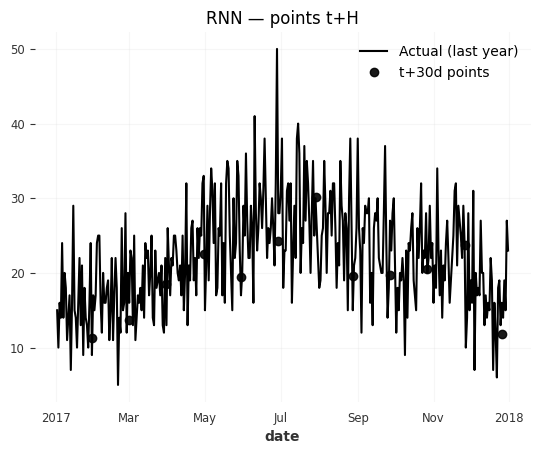

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 55.3 K | train
6 | V               | Linear           | 65     | train
-------------------------------------------------------------
55.4 K    Trainable params
0         Non-trainable params
55.4 K    Total params
0.221     Total estimated model params size (MB)
7         

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection |

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection |

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection |

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection |

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


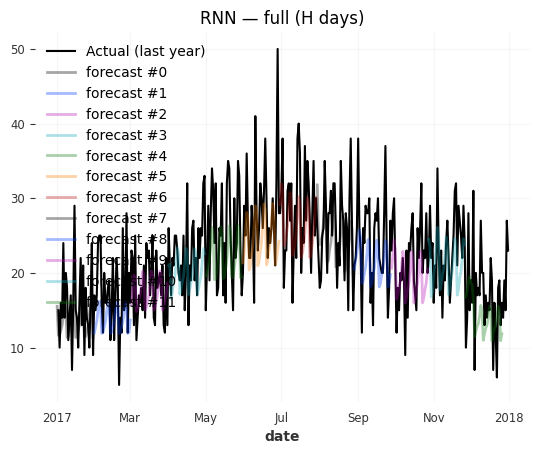

[RNN] MAPE (concatenated paths): 19.619


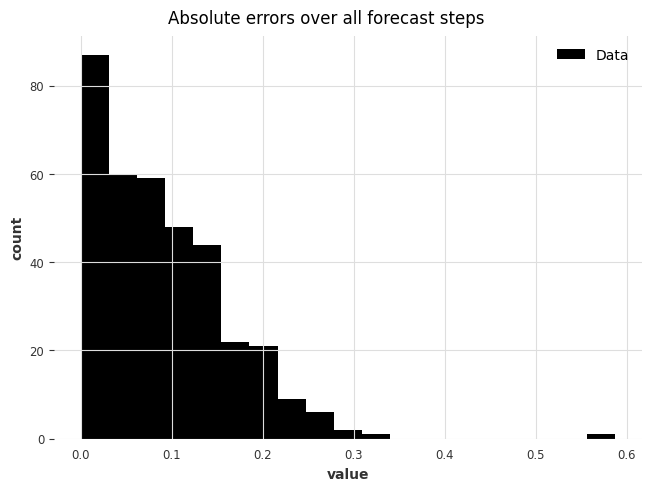

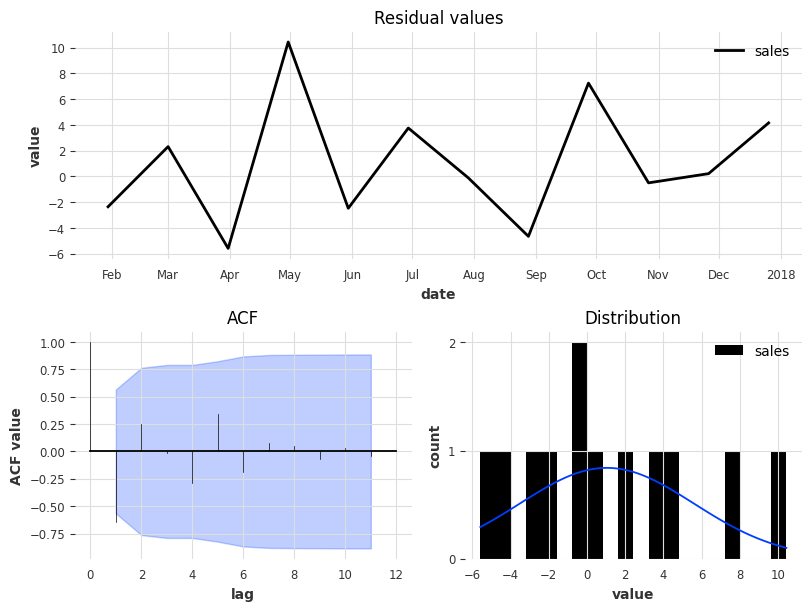

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 55.3 K | train
6 | V               | Linear           | 65     | train
-------------------------------------------------------------
55.4 K    Trainable params
0         Non-trainable params
55.4 K    Total params
0.221     Total estimated model params size (MB)
7         

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection |

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection |

...

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection |

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


[RNN] Average MAPE via backtest(): last_points=25.989 | all_steps=27.592


In [44]:
#RNN (LSTM) residuals

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darts.metrics import mape, smape, rmse, ae
from darts.utils.statistics import plot_hist, plot_residuals_analysis

# concat helper (Darts versions troubleshooting)
try:
    from darts import concatenate
except ImportError:
    from darts.utils.utils import concatenate

# Historical forecasts: only points t+H (like backtest)
hfc_last_scaled = model.historical_forecasts(
    series=series_y,
    future_covariates=future_cov_s,
    start=backtest_start,
    forecast_horizon=horizon_days,
    stride=stride_days,
    retrain=True,               # True
    last_points_only=True,
    verbose=False,
)
hfc_last = y_scaler.inverse_transform(hfc_last_scaled)

print(f"[RNN] MAPE (last_points_only, H={horizon_days}): {mape(series, hfc_last):.3f}")

ax = series.drop_before(backtest_start).plot(label="Actual (last year)", color="black", lw=1.5)
plt.plot(hfc_last.time_index, hfc_last.values().flatten(),
         marker="o", linestyle="none", label=f"t+{horizon_days}d points", alpha=0.9)
plt.legend(); plt.grid(alpha=0.25); plt.title("RNN — points t+H"); plt.show()

# Historical forecasts: full path on H days
hfc_paths_scaled = model.historical_forecasts(
    series=series_y,
    future_covariates=future_cov_s,
    start=backtest_start,
    forecast_horizon=horizon_days,
    stride=stride_days,
    retrain=True,
    last_points_only=False,
    verbose=False,
)
hfc_paths = [y_scaler.inverse_transform(fc) for fc in hfc_paths_scaled]

ax = series.drop_before(backtest_start).plot(label="Actual (last year)", color="black", lw=1.5)
for i, fc in enumerate(hfc_paths):
    fc.plot(label=f"forecast #{i}", alpha=0.35, ax=ax)
plt.legend(); plt.grid(alpha=0.25); plt.title("RNN — full (H days)"); plt.show()

#concat
hfc_concat = concatenate(hfc_paths, axis=0)
print(f"[RNN] MAPE (concatenated paths): {mape(series, hfc_concat):.3f}")

# hist raw errors (Absolute Error)
res_arrays = model.residuals(
    series=series_y,
    historical_forecasts=hfc_paths_scaled,  # scaled
    metric=ae,
    last_points_only=False,
    values_only=True
)
all_ae = np.concatenate(res_arrays, axis=None)
bins = np.linspace(0, np.nanmax(all_ae), 20)
plot_hist(all_ae[~np.isnan(all_ae)], bins=bins, title="Absolute errors over all forecast steps")
plt.show()

# residuals analysis in pts t+H (ACF, QQ-plot, seasonality)
res_last = series.slice_intersect(hfc_last) - hfc_last
plot_residuals_analysis(res_last)
plt.show()

#avarageerror backtest() (last points vs all steps)
avg_mape_last = model.backtest(
    series=series_y,
    future_covariates=future_cov_s,
    start=backtest_start,
    forecast_horizon=horizon_days,
    stride=stride_days,
    retrain=True,
    metric=mape,
    reduction=np.mean,
    last_points_only=True,
    verbose=False,
)
avg_mape_paths = model.backtest(
    series=series_y,
    future_covariates=future_cov_s,
    start=backtest_start,
    forecast_horizon=horizon_days,
    stride=stride_days,
    retrain=True,
    metric=mape,
    reduction=np.mean,
    last_points_only=False,
    verbose=False,
)
print(f"[RNN] Average MAPE via backtest(): last_points={avg_mape_last:.3f} | all_steps={avg_mape_paths:.3f}")


Висновок:

- Prophet:
    - MAPE: 24.490
    - RSME: 5.056

- XGB:
    - MAPE: 20.913
    - RSME: 5.123
- RNN:
    - MAPE: 19.24
    - RSME: 4.68


RNN (LSTM) - найкраща модель. На бек-тесті за останній рік із щомісячним горизонтом вона дала найменшу помилку MAPE (прибл. 19%), стабільно кращу за Prophet і XGB. Модель добре тримає тренд і тижневу сезонність, роблячи рівні, узгоджені прогнози, інколи занижує різкі піки. Очевидна перевага Prophet - мінімум параметрів, швидко працює і відносно ARIMA гарний результат.

Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

Відповідь:


- Одна глобальна RNN (LSTM) у Darts з календарними future-covariates (day-of-week, month, day-of-year, за можливості — свята/акції).
-  Для контролю якості — прості бенчмарки: Theta / Exponential Smoothing.


- 1 глобальна RNN на всі 500 серій (50 одиниць на 10 магазинів)
- Як варіант, якщо ряди дуже різні (магазини, де мало продажів vs популярні) - можливо б розбив всі магазини на ці 2-3 кластери - 2–3 глобальні RNN.
- Плюс 1–2 бенчмарки  (Theta/Exponential Smoothing) для моніторингу.



- RNN дала найменший MAPE. Як глобальна модель вона переносить спільні патерни між serias, краще тримає тижневу сезонність і не вимагає тюнити 500 окремих моделей (як ARIMA/Prophet).
- Theta/Exponential Smoothing швидкі й стабільні як бенчмарк.

